<a href="https://colab.research.google.com/github/JAYMAN735/ML-Projects/blob/main/iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [ ]:
df=load_iris()

In [ ]:
df_iris = pd.DataFrame(df.data, columns=df.feature_names)
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
df_iris['species_id'] = df.target
df_iris['species'] = df_iris['species_id'].map(lambda x: df.target_names[x])
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


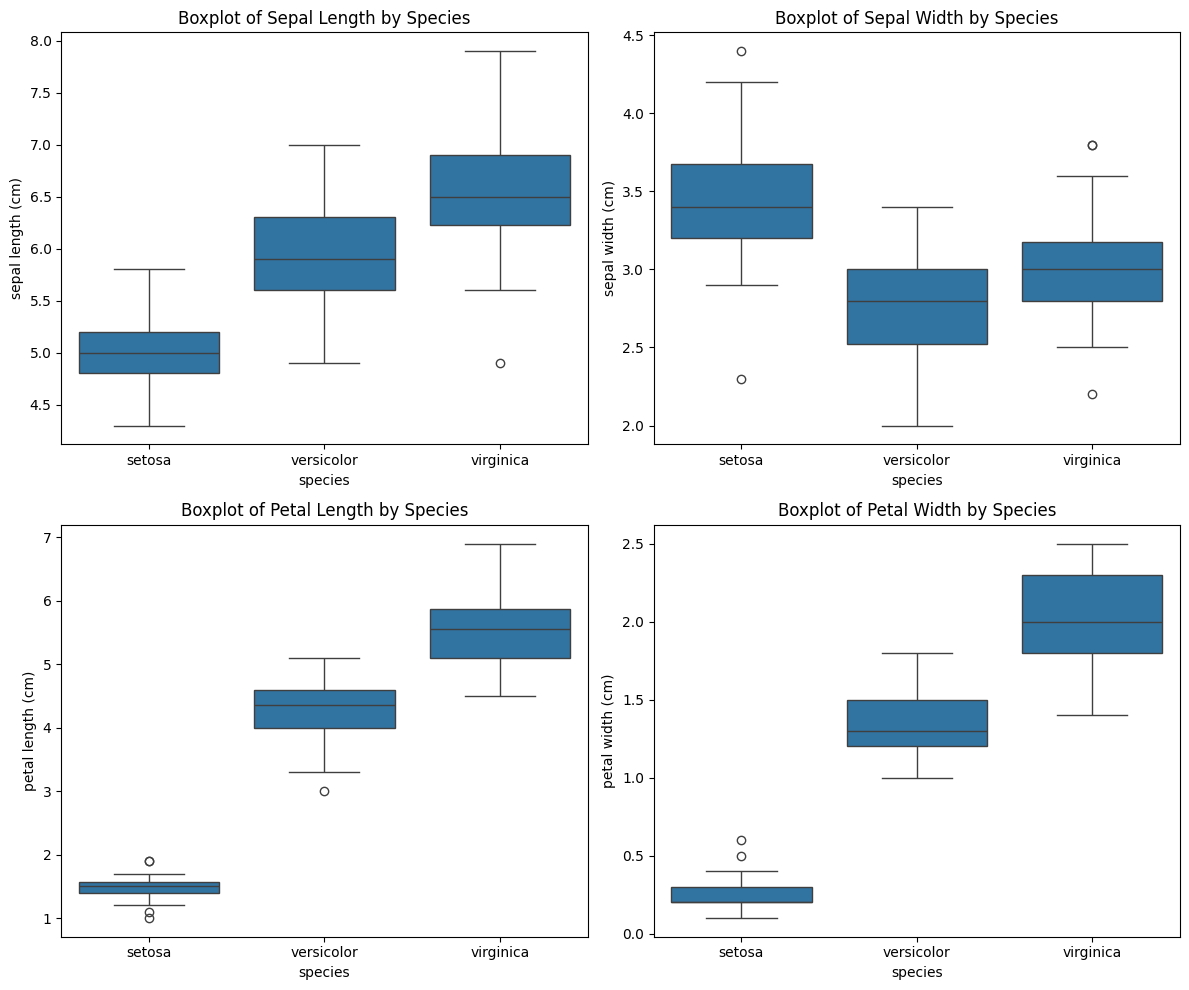

In [ ]:
numerical_features = df_iris.drop(columns=['species_id', 'species']).columns

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(x='species', y=feature, data=df_iris, ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature.replace(" (cm)", "").title()} by Species')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

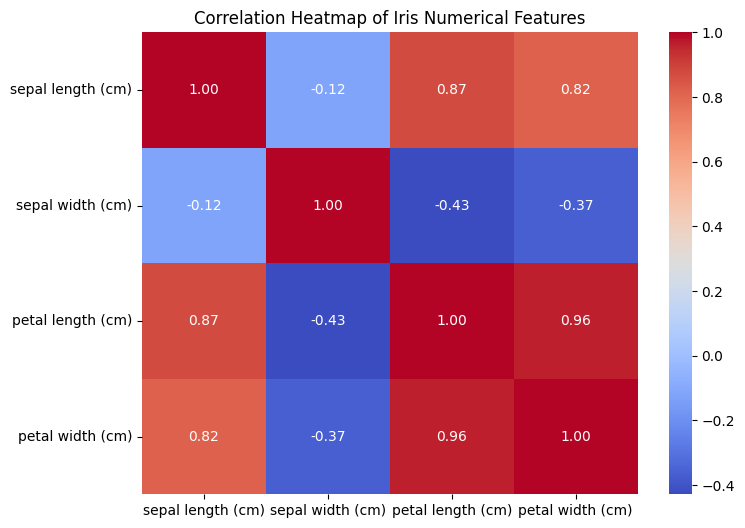

In [ ]:
correlation_matrix = df_iris[numerical_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Iris Numerical Features')
plt.show()

# Task
Perform K-Means clustering with k=3 on the numerical features of the Iris dataset, store the cluster assignments in a new column in the DataFrame, then visualize the clusters against actual species, and finally evaluate the clustering alignment using relevant metrics.

## Perform K-Means Clustering

### Subtask:
Apply K-Means clustering with k=3 to the numerical features of the Iris dataset. Store the cluster assignments in a new column in the DataFrame.


**Reasoning**:
First, I'll import the KMeans class from sklearn.cluster to perform K-Means clustering. Then, I'll extract the numerical features from the dataframe, initialize the KMeans model with 3 clusters and a random state for reproducibility, fit the model to the numerical data, and finally assign the resulting cluster labels to a new column in the DataFrame.



In [ ]:
from sklearn.cluster import KMeans

# Extract numerical features
numerical_features_data = df_iris[numerical_features]

# Initialize KMeans model
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

# Fit KMeans model and store cluster assignments
df_iris['cluster_assignment'] = kmeans.fit_predict(numerical_features_data)

print("K-Means clustering applied and cluster_assignment column added.")
print(df_iris.head())

K-Means clustering applied and cluster_assignment column added.
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species_id species  cluster_assignment  
0           0  setosa                   1  
1           0  setosa                   1  
2           0  setosa                   1  
3           0  setosa                   1  
4           0  setosa                   1  


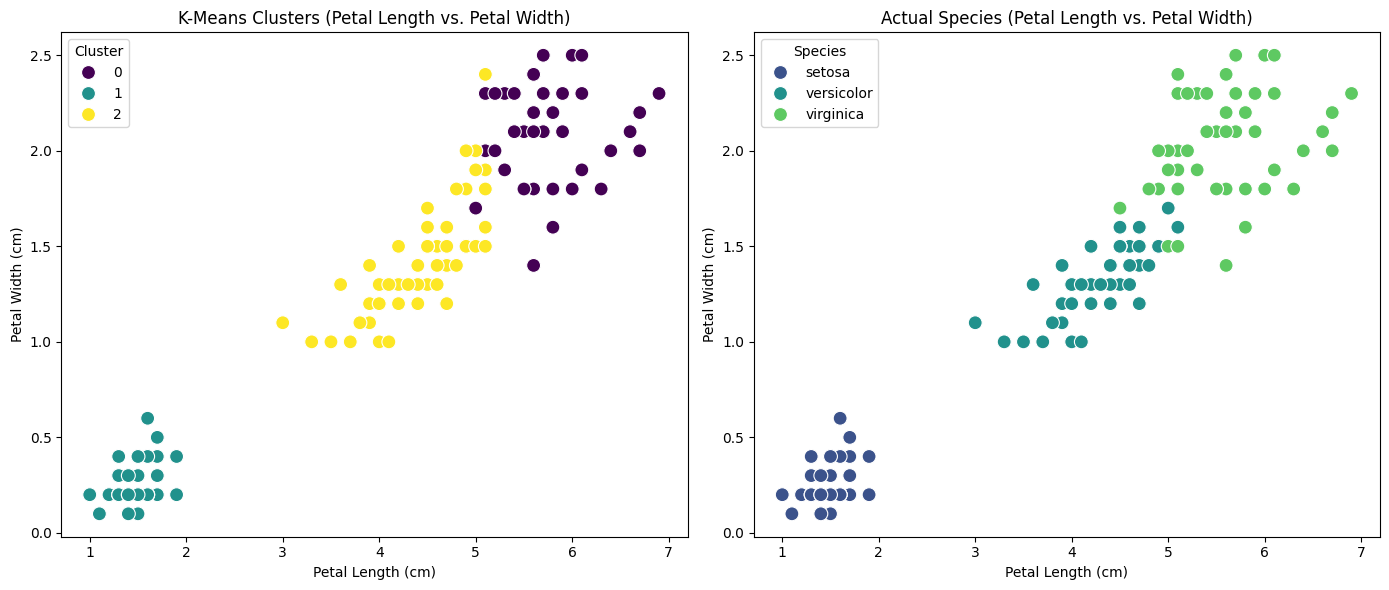

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot K-Means Clusters
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='cluster_assignment',
    data=df_iris,
    palette='viridis',
    ax=axes[0],
    s=100
)
axes[0].set_title('K-Means Clusters (Petal Length vs. Petal Width)')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].legend(title='Cluster')

# Plot Actual Species
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    data=df_iris,
    palette='viridis',
    ax=axes[1],
    s=100
)
axes[1].set_title('Actual Species (Petal Length vs. Petal Width)')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend(title='Species')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score

# Create a cross-tabulation
cross_tab = pd.crosstab(df_iris['species'], df_iris['cluster_assignment'])
print("Cross-Tabulation of Actual Species vs. K-Means Clusters:\n", cross_tab)

# Calculate Adjusted Rand Index
ari = adjusted_rand_score(df_iris['species_id'], df_iris['cluster_assignment'])
print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")

# Calculate Homogeneity Score
homogeneity = homogeneity_score(df_iris['species_id'], df_iris['cluster_assignment'])
print(f"Homogeneity Score: {homogeneity:.4f}")

# Calculate Completeness Score
completeness = completeness_score(df_iris['species_id'], df_iris['cluster_assignment'])
print(f"Completeness Score: {completeness:.4f}")

# Calculate V-measure Score
v_measure = v_measure_score(df_iris['species_id'], df_iris['cluster_assignment'])
print(f"V-measure Score: {v_measure:.4f}")

Cross-Tabulation of Actual Species vs. K-Means Clusters:
 cluster_assignment   0   1   2
species                       
setosa               0  50   0
versicolor           3   0  47
virginica           36   0  14

Adjusted Rand Index (ARI): 0.7163
Homogeneity Score: 0.7364
Completeness Score: 0.7475
V-measure Score: 0.7419


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model Accuracy: 0.9111

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


Confusion Matrix:


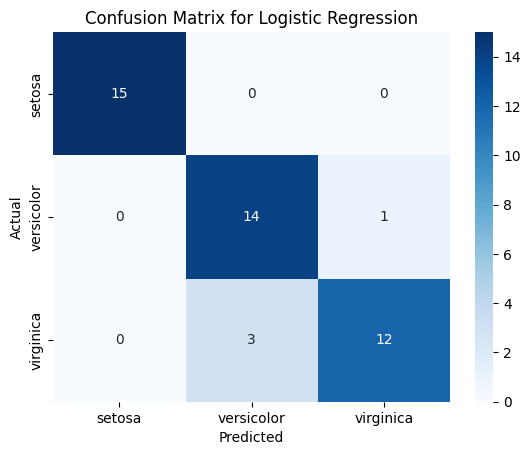

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define features (X) and target (y)
X = df_iris[numerical_features]
y = df_iris['species_id']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, multi_class='multinomial', solver='lbfgs')
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test_scaled)

# Evaluate model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=df.target_names))

# Display confusion matrix
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=df.target_names, yticklabels=df.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [ ]:
print("First 5 rows of the DataFrame:")
print(df_iris.head())

print("\nDataFrame Info:")
df_iris.info()

print("\nDescriptive statistics for numerical features:")
print(df_iris.describe())

First 5 rows of the DataFrame:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species_id species  cluster_assignment  
0           0  setosa                   1  
1           0  setosa                   1  
2           0  setosa                   1  
3           0  setosa                   1  
4           0  setosa                   1  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sepal 

In [ ]:
print("Missing values per column:")
print(df_iris.isnull().sum())

Missing values per column:
sepal length (cm)     0
sepal width (cm)      0
petal length (cm)     0
petal width (cm)      0
species_id            0
species               0
cluster_assignment    0
dtype: int64


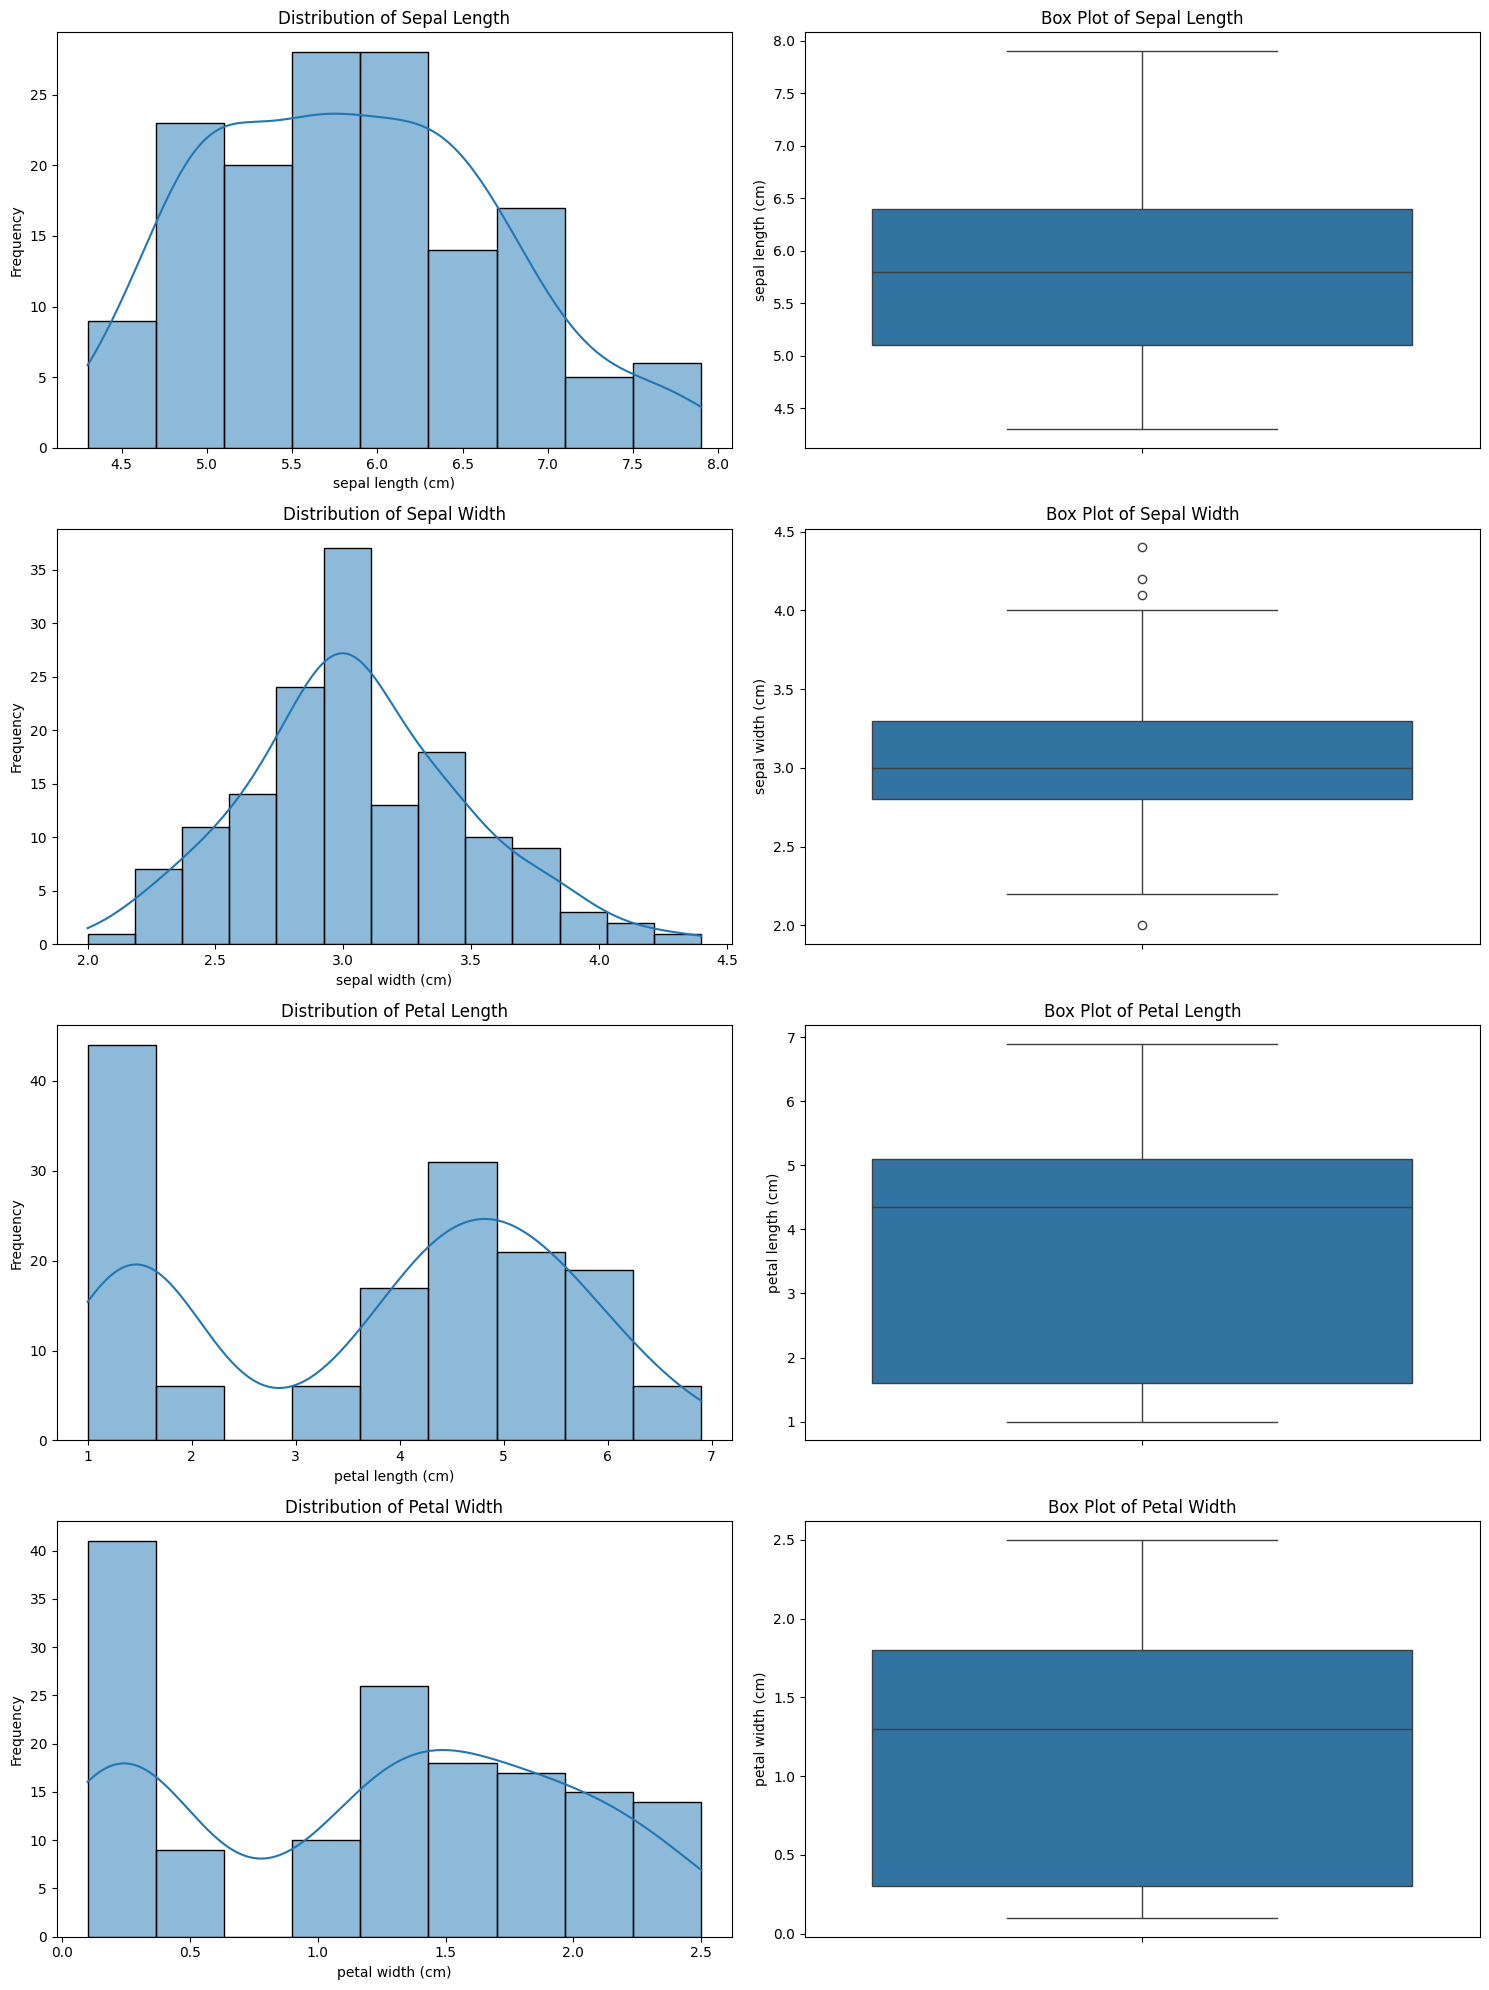

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    # Histogram
    sns.histplot(df_iris[feature], kde=True, ax=axes[2*i])
    axes[2*i].set_title(f'Distribution of {feature.replace(" (cm)", "").title()}')
    axes[2*i].set_xlabel(feature)
    axes[2*i].set_ylabel('Frequency')

    # Box Plot
    sns.boxplot(y=df_iris[feature], ax=axes[2*i + 1])
    axes[2*i + 1].set_title(f'Box Plot of {feature.replace(" (cm)", "").title()}')
    axes[2*i + 1].set_ylabel(feature)

plt.tight_layout()
plt.show()

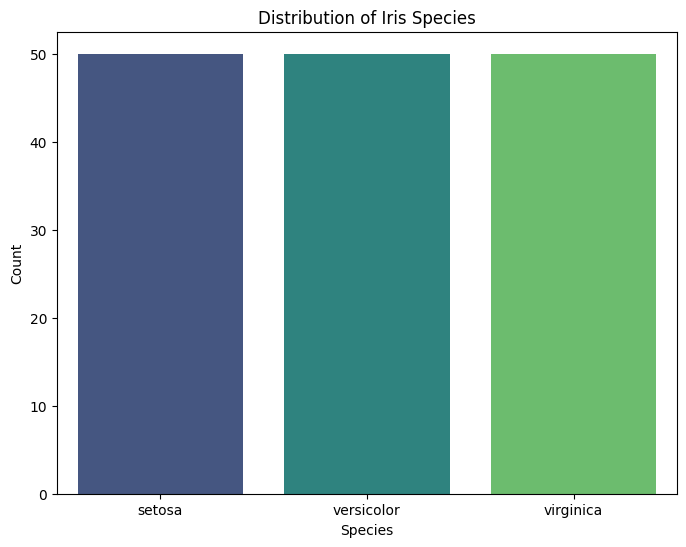

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='species', data=df_iris, palette='viridis', hue='species', legend=False)
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

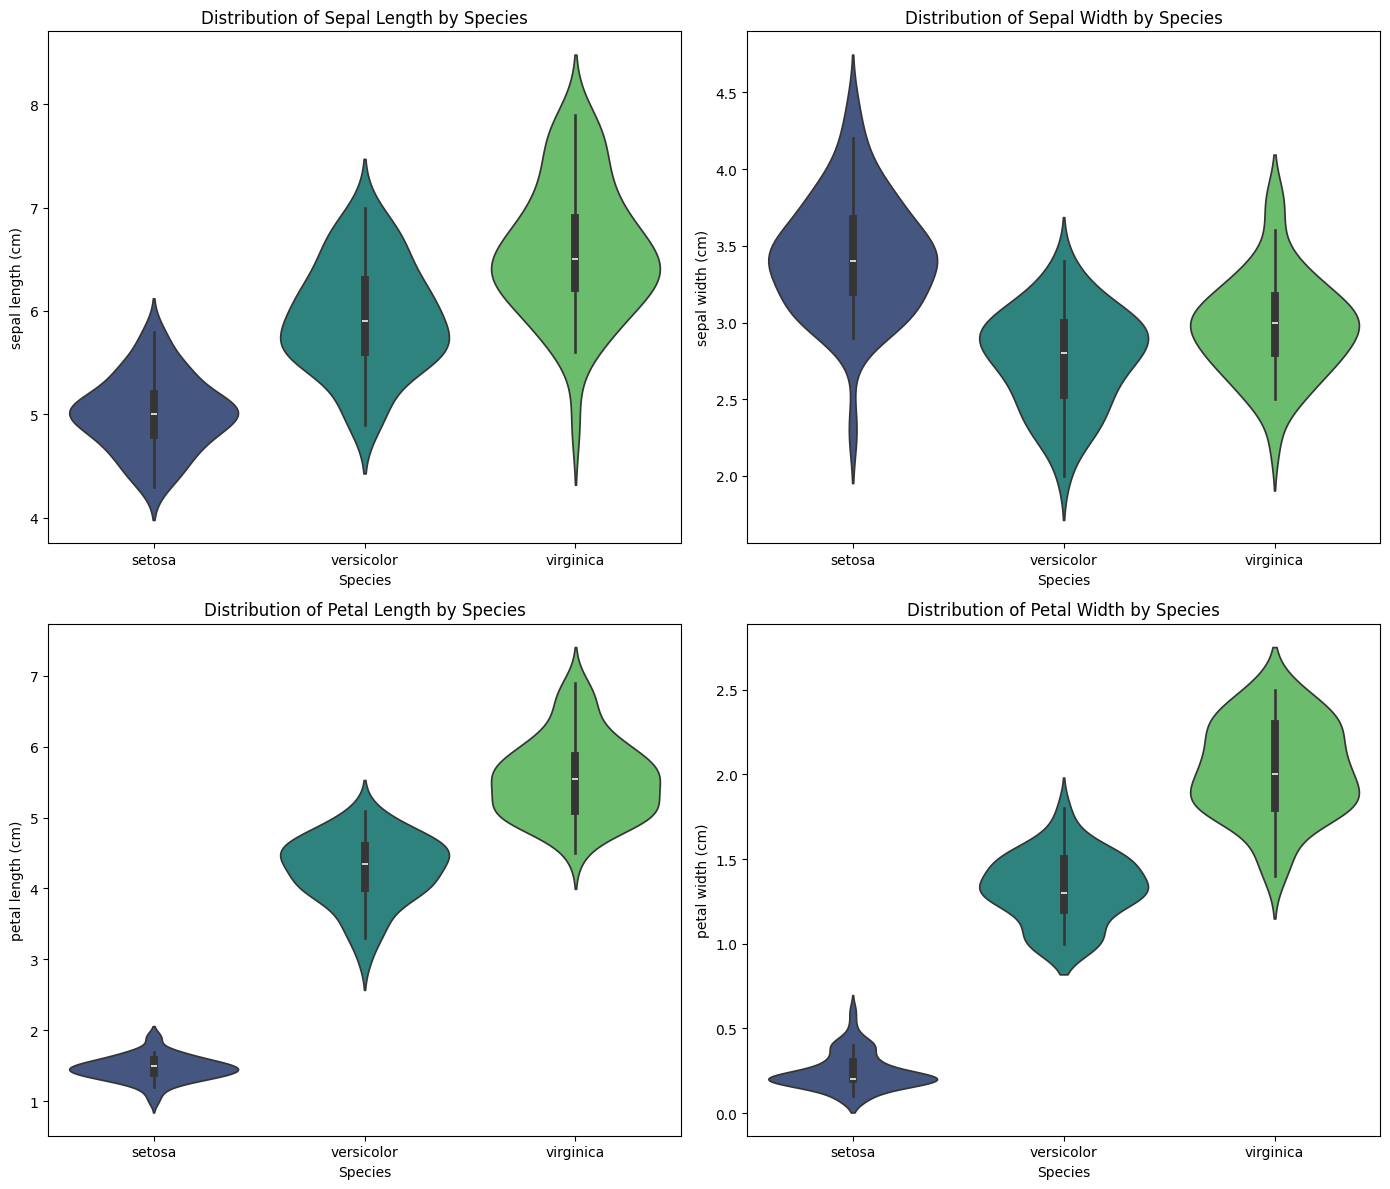

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.violinplot(x='species', y=feature, data=df_iris, ax=axes[i], palette='viridis', hue='species', legend=False)
    axes[i].set_title(f'Distribution of {feature.replace(" (cm)", "").title()} by Species')
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

Naïve Bayes Model Accuracy: 0.9111

Naïve Bayes Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


Naïve Bayes Confusion Matrix:


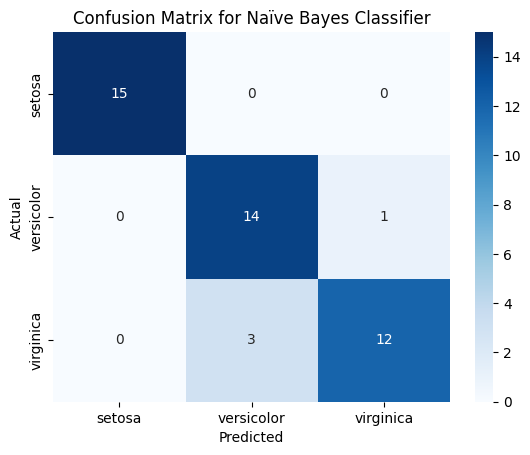

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Naïve Bayes model
naive_bayes_model = GaussianNB()

# Train the model
naive_bayes_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_nb = naive_bayes_model.predict(X_test_scaled)

# Evaluate model accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naïve Bayes Model Accuracy: {accuracy_nb:.4f}")

# Display classification report
print("\nNaïve Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=df.target_names))

# Display confusion matrix
print("\nNaïve Bayes Confusion Matrix:")
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues', xticklabels=df.target_names, yticklabels=df.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naïve Bayes Classifier')
plt.show()

# Task
Implement a k-Nearest Neighbors (kNN) classifier on the Iris dataset. Evaluate the model's accuracy for 'k' values ranging from 1 to 20 using `X_train_scaled`, `X_test_scaled`, `y_train`, and `y_test`. Visualize the accuracy scores against the 'k' values using a line plot, then identify and comment on the optimal 'k' value and its impact on the classifier's performance.

## Implement kNN and Evaluate for Multiple k

### Subtask:
Initialize and train a k-Nearest Neighbors (kNN) classifier using the `X_train_scaled` and `y_train` data. Iterate through a range of 'k' values (e.g., from 1 to 20). For each 'k', predict on `X_test_scaled` and calculate the `accuracy_score`. Store the accuracies for each 'k' value.


**Reasoning**:
The subtask requires implementing kNN and iterating through different 'k' values to calculate and store accuracy scores. This step involves importing necessary libraries, initializing a list to store accuracies, and then looping through the specified range of 'k' values to train the kNN model, make predictions, and record the accuracy for each 'k'.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracy_scores = []

# Loop through 'k' values from 1 to 20
for k in range(1, 21):
    # Initialize KNeighborsClassifier with the current 'k'
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the kNN classifier to the training data
    knn.fit(X_train_scaled, y_train)

    # Make predictions on the test data
    y_pred_knn = knn.predict(X_test_scaled)

    # Calculate accuracy score
    accuracy_knn = accuracy_score(y_test, y_pred_knn)

    # Append accuracy to the list
    accuracy_scores.append(accuracy_knn)

print("Accuracy scores for k values from 1 to 20:")
for i, score in enumerate(accuracy_scores):
    print(f"k = {i+1}: {score:.4f}")

Accuracy scores for k values from 1 to 20:
k = 1: 0.9333
k = 2: 0.8889
k = 3: 0.9111
k = 4: 0.9111
k = 5: 0.9111
k = 6: 0.9111
k = 7: 0.9333
k = 8: 0.9111
k = 9: 0.9556
k = 10: 0.9333
k = 11: 0.9556
k = 12: 0.9556
k = 13: 0.9333
k = 14: 0.9556
k = 15: 0.9333
k = 16: 0.9111
k = 17: 0.9111
k = 18: 0.9111
k = 19: 0.9111
k = 20: 0.8889


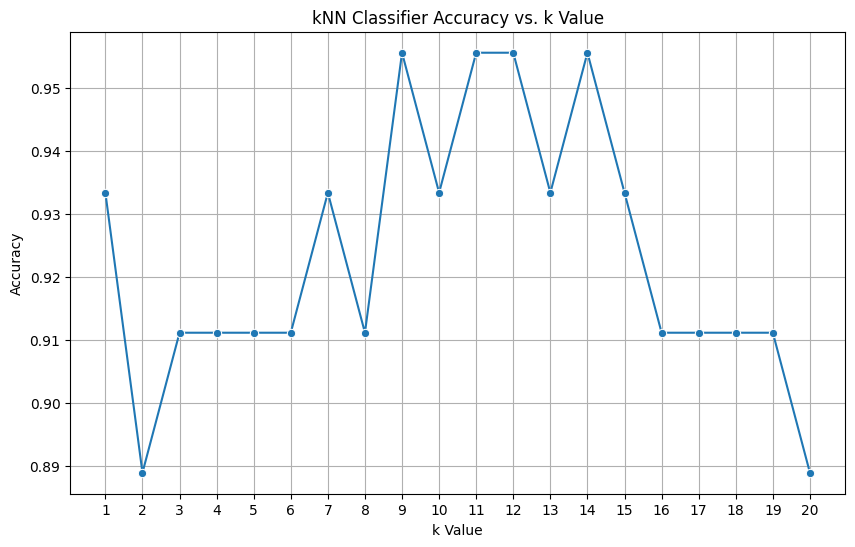

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

k_values = list(range(1, 21))

plt.figure(figsize=(10, 6))
sns.lineplot(x=k_values, y=accuracy_scores, marker='o')
plt.title('kNN Classifier Accuracy vs. k Value')
plt.xlabel('k Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
wcss_values = []

# Loop through 'k' values from 1 to 15
for k in range(1, 16):
    # Initialize KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

    # Fit KMeans model to the numerical features data
    kmeans.fit(numerical_features_data)

    # Append the WCSS (inertia_) to the list
    wcss_values.append(kmeans.inertia_)

print("WCSS values for k from 1 to 15:")
for i, wcss in enumerate(wcss_values):
    print(f"k = {i+1}: {wcss:.2f}")

WCSS values for k from 1 to 15:
k = 1: 681.37
k = 2: 152.35
k = 3: 78.86
k = 4: 57.35
k = 5: 46.47
k = 6: 39.07
k = 7: 34.31
k = 8: 30.48
k = 9: 29.91
k = 10: 28.55
k = 11: 26.51
k = 12: 25.86
k = 13: 23.42
k = 14: 22.24
k = 15: 21.15


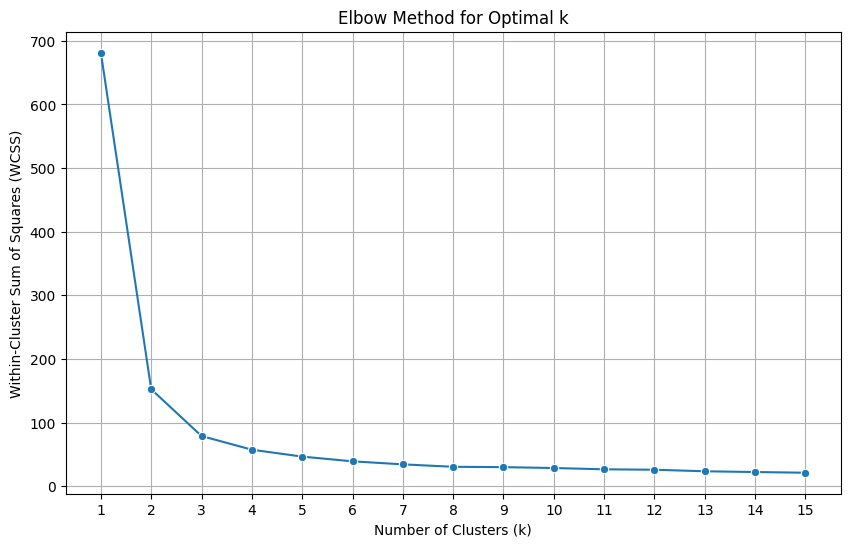

In [ ]:
k_values = list(range(1, 16))

plt.figure(figsize=(10, 6))
sns.lineplot(x=k_values, y=wcss_values, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

## Build Decision Tree Classifier

### Subtask:
Initialize and train a Decision Tree Classifier on the `X_train_scaled` and `y_train` data. Ensure to use a `random_state` for reproducibility.


**Reasoning**:
The subtask requires importing the `DecisionTreeClassifier`, instantiating it with a `random_state`, and then training the model using the provided scaled training data. This will be done in a single code block to complete the initialization and training steps.



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate a DecisionTreeClassifier object with random_state=42
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the classifier using the .fit() method
decision_tree_model.fit(X_train_scaled, y_train)

print("Decision Tree Classifier initialized and trained successfully.")

Decision Tree Classifier initialized and trained successfully.


**Reasoning**:
The next step is to visualize the trained Decision Tree structure using `plot_tree`, including feature and class names, to understand its decision-making process.



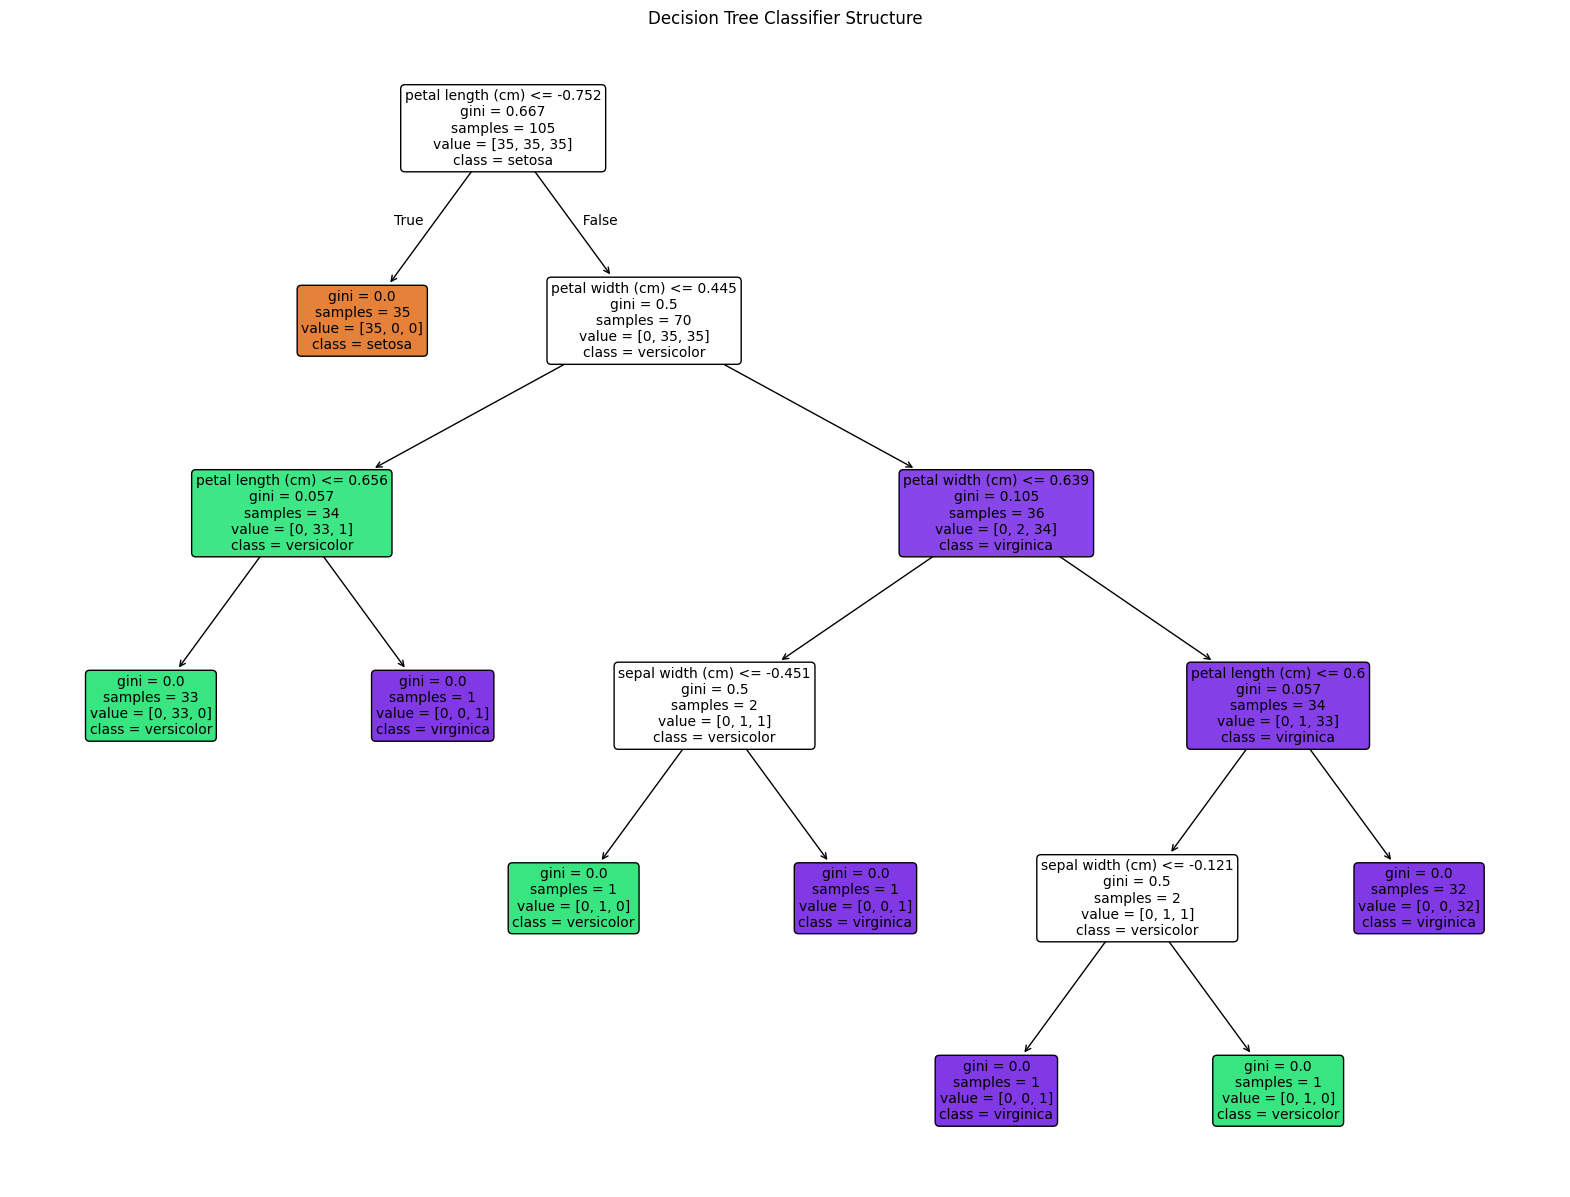

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plot_tree(decision_tree_model,
          feature_names=numerical_features.tolist(),
          class_names=df.target_names.tolist(),
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Classifier Structure')
plt.show()

**Reasoning**:
After visualizing the decision tree, the next step is to identify the most important features as indicated by the trained Decision Tree model. The `feature_importances_` attribute of the `decision_tree_model` will provide these values, which can then be mapped to their corresponding feature names for clarity.



In [ ]:
feature_importances = decision_tree_model.feature_importances_

# Create a pandas Series for better readability
feature_importance_series = pd.Series(feature_importances, index=numerical_features)

print("Feature Importances:")
print(feature_importance_series.sort_values(ascending=False))

# Identify the most important feature
most_important_feature = feature_importance_series.idxmax()
print(f"\nMost Important Feature: {most_important_feature}")

Feature Importances:
petal length (cm)    0.541176
petal width (cm)     0.430252
sepal width (cm)     0.028571
sepal length (cm)    0.000000
dtype: float64

Most Important Feature: petal length (cm)


**Reasoning**:
To summarize the Decision Tree Classifier's performance, I will first predict on the scaled test data, calculate the accuracy score, and then present the accuracy along with the most important feature and a note about the visualized tree.



In [ ]:
from sklearn.metrics import accuracy_score

y_pred_dt = decision_tree_model.predict(X_test_scaled)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Classifier Accuracy: {accuracy_dt:.4f}")
print(f"\nMost important feature identified by the Decision Tree: {most_important_feature}")
print("The Decision Tree structure was visualized to understand its decision-making process.")

Decision Tree Classifier Accuracy: 0.9111

Most important feature identified by the Decision Tree: petal length (cm)
The Decision Tree structure was visualized to understand its decision-making process.


## Implement Support Vector Machine (SVM) Classifier

### Subtask:
Initialize and train a Support Vector Machine (SVM) classifier on the `X_train_scaled` and `y_train` data. Evaluate the model's accuracy, display a classification report, and visualize the confusion matrix.

**Reasoning**:
First, I'll import the `SVC` class from `sklearn.svm` to implement the SVM classifier. Then, I'll initialize the `SVC` model with a `random_state` for reproducibility and train it using the `fit` method on the `X_train_scaled` and `y_train` data. After training, I'll use the `predict` method to get predictions on the `X_test_scaled` data. Finally, I will evaluate the model's performance by calculating and printing the accuracy score, a classification report, and visualizing the confusion matrix using `seaborn.heatmap`.

SVM Model Accuracy: 0.9333

SVM Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


SVM Confusion Matrix:


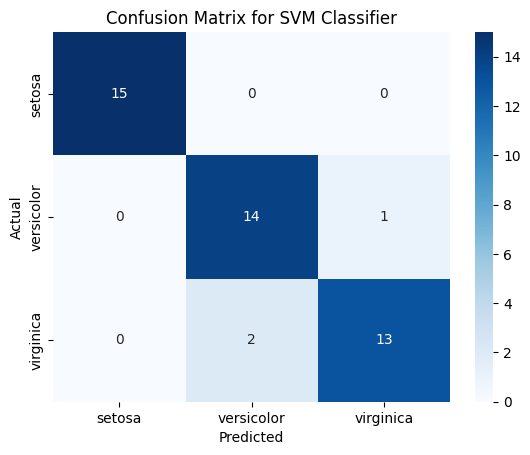

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize SVM classifier
svm_model = SVC(random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate model accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Model Accuracy: {accuracy_svm:.4f}")

# Display classification report
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=df.target_names))

# Display confusion matrix
print("\nSVM Confusion Matrix:")
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues', xticklabels=df.target_names, yticklabels=df.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

## Implement Random Forest Classifier

### Subtask:
Initialize and train a Random Forest Classifier on the `X_train_scaled` and `y_train` data. Evaluate the model's accuracy, display a classification report, and visualize the confusion matrix.

**Reasoning**:
First, I'll import the `RandomForestClassifier` from `sklearn.ensemble`. Then, I'll initialize the model with a `random_state` for reproducibility and train it using the `fit` method on the `X_train_scaled` and `y_train` data. After training, I'll use the `predict` method to get predictions on the `X_test_scaled` data. Finally, I will evaluate the model's performance by calculating and printing the accuracy score, a classification report, and visualizing the confusion matrix using `seaborn.heatmap`.

Random Forest Model Accuracy: 0.8889

Random Forest Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45


Random Forest Confusion Matrix:


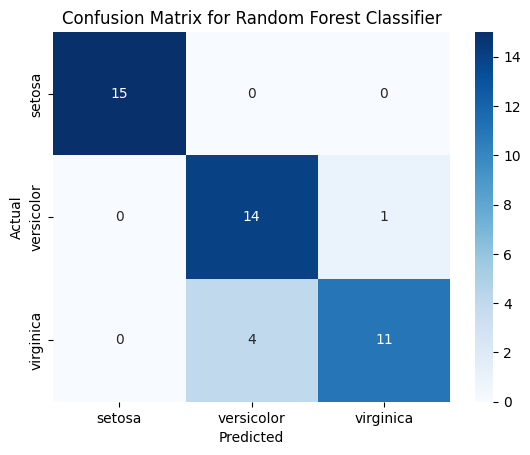

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate model accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")

# Display classification report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=df.target_names))

# Display confusion matrix
print("\nRandom Forest Confusion Matrix:")
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=df.target_names, yticklabels=df.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()